In [56]:
!pip install -U scikit-learn==1.8.0


## Data Loading

In [57]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Read the data
train_data = pd.read_csv('/kaggle/input/home-data-for-ml-course/train.csv', index_col="Id")
test_data = pd.read_csv('/kaggle/input/home-data-for-ml-course/test.csv', index_col = 'Id')
print(f'The size of train data{train_data.shape} , the size of test data{test_data.shape}' )


The size of train data(1460, 80) , the size of test data(1459, 79)


## Data Preprocessing

I will impute these values later.

In [58]:
print(f'Missing values in train set:{train_data.isnull().sum().sum()} and test set:{test_data.isnull().sum().sum()}')

Missing values in train set:7829 and test set:7878


In [59]:
nr_cols = train_data.select_dtypes(include=['int64', 'float64']).columns
corrs = train_data[nr_cols].corrwith(train_data['SalePrice'])
corrs




MSSubClass      -0.084284
LotFrontage      0.351799
LotArea          0.263843
OverallQual      0.790982
OverallCond     -0.077856
YearBuilt        0.522897
YearRemodAdd     0.507101
MasVnrArea       0.477493
BsmtFinSF1       0.386420
BsmtFinSF2      -0.011378
BsmtUnfSF        0.214479
TotalBsmtSF      0.613581
1stFlrSF         0.605852
2ndFlrSF         0.319334
LowQualFinSF    -0.025606
GrLivArea        0.708624
BsmtFullBath     0.227122
BsmtHalfBath    -0.016844
FullBath         0.560664
HalfBath         0.284108
BedroomAbvGr     0.168213
KitchenAbvGr    -0.135907
TotRmsAbvGrd     0.533723
Fireplaces       0.466929
GarageYrBlt      0.486362
GarageCars       0.640409
GarageArea       0.623431
WoodDeckSF       0.324413
OpenPorchSF      0.315856
EnclosedPorch   -0.128578
3SsnPorch        0.044584
ScreenPorch      0.111447
PoolArea         0.092404
MiscVal         -0.021190
MoSold           0.046432
YrSold          -0.028923
SalePrice        1.000000
dtype: float64

I will focus on the features that show a correlation above 0.6 with the target

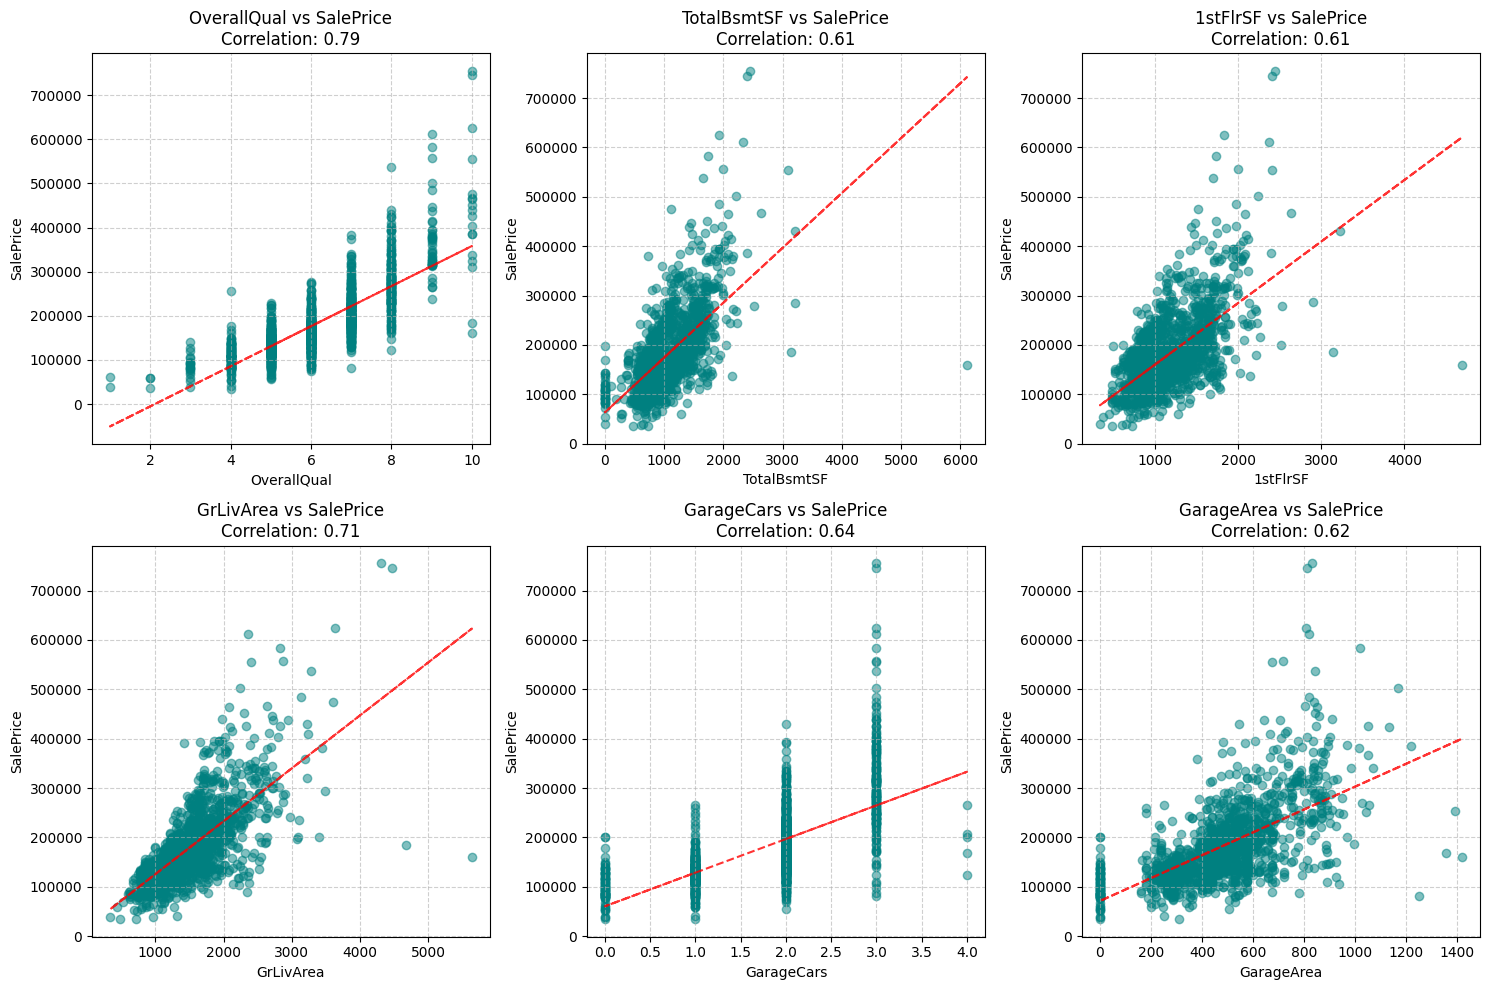

Features with a correlation above 0.6 are : ['OverallQual', 'TotalBsmtSF', '1stFlrSF', 'GrLivArea', 'GarageCars', 'GarageArea']


In [60]:
high_corr_features = corrs[corrs > 0.6].index.tolist()
if 'SalePrice' in high_corr_features:
    high_corr_features.remove('SalePrice')


# Determine how many rows and columns we need.
n_features = len(high_corr_features)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

plt.figure(figsize=(n_cols * 5, n_rows * 5))

for i, col in enumerate(high_corr_features):
    plt.subplot(n_rows, n_cols, i + 1)
    
    # Scatter plot
    plt.scatter(train_data[col], train_data['SalePrice'], alpha=0.5, color='teal')
    
    # I will add a trendline in the chart
    z = np.polyfit(train_data[col], train_data['SalePrice'], 1)
    p = np.poly1d(z)
    plt.plot(train_data[col], p(train_data[col]), "r--", alpha=0.8)
    
    plt.title(f"{col} vs SalePrice\nCorrelation: {corrs[col]:.2f}")
    plt.xlabel(col)
    plt.ylabel("SalePrice")
    plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

print(f"Features with a correlation above 0.6 are : {high_corr_features}")

We have a few outliers in the 'GarageArea vs SalePrice', 'TotalBsmtSF vs SalePrice', '1stFlrSF vs SalePrice' and 'GrLivArea vs SalePrice' plots that could cause problems later on.

In [61]:
train_data = train_data.drop(train_data[(train_data['GrLivArea'] > 4000) 
                             & (train_data['SalePrice'] < 300_000)].index)
train_data = train_data.drop(train_data[(train_data['GarageArea'] > 1200) 
                             & (train_data['SalePrice'] < 300_000)].index)
train_data = train_data.drop(train_data[(train_data['TotalBsmtSF'] > 4000) 
                             & (train_data['SalePrice'] < 300_000)].index)
train_data = train_data.drop(train_data[(train_data['1stFlrSF'] > 4000) 
                             & (train_data['SalePrice'] < 300_000)].index)

print(f'The size of train data{train_data.shape} , the size of test data{test_data.shape}' )

The size of train data(1455, 80) , the size of test data(1459, 79)


## Training and Evaluation

In [62]:
#Remove rows with missing target
train_data.dropna(axis=0, subset='SalePrice', inplace=True)
y = train_data['SalePrice']
train_data.drop(['SalePrice'], axis = 1 , inplace = True)
# Break off valitation set from training set
X_train_full, X_valid_full, y_train, y_valid =  train_test_split(train_data, y,
                                                                 train_size= 0.8, 
                                                                 test_size = 0.2,
                                                                random_state=0)
low_cardinality_cols = [col for col in X_train_full.columns 
                        if X_train_full[col].nunique() <10 and
                       X_train_full[col].dtype == 'object']

numeric_cols = [col for col in X_train_full.columns 
                if X_train_full[col].dtype in ['int64','float64']]
print( low_cardinality_cols)
print(numeric_cols)

#
valid_cols = low_cardinality_cols + numeric_cols
X_train = X_train_full[valid_cols].copy()
X_valid = X_valid_full[valid_cols].copy()
X_test = test_data[valid_cols].copy()
print("\n")
print(f'The size of train data{X_train.shape} , the size of test data{y.shape}' )

['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']
['MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolAre

In [63]:
# Break off the columns for ordinal encoding from all categorical columns.
categorical_cols_ordinal= ['HeatingQC','PoolQC','GarageQual','GarageCond','FireplaceQu', 'KitchenQual','BsmtCond','BsmtQual','ExterQual']
categorical_cols_one_hot = [col for col in low_cardinality_cols if col  not in categorical_cols_ordinal ]
print(categorical_cols_ordinal)
print()
print(categorical_cols_one_hot)

['HeatingQC', 'PoolQC', 'GarageQual', 'GarageCond', 'FireplaceQu', 'KitchenQual', 'BsmtCond', 'BsmtQual', 'ExterQual']

['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'MasVnrType', 'ExterCond', 'Foundation', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'CentralAir', 'Electrical', 'Functional', 'GarageType', 'GarageFinish', 'PavedDrive', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']


Here I will handle the missing values automatically using the SimpleImputer function from sklearn. I will also define a pipeline that will automatically perform imputation, encoding, and model construction.

In [64]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error


# Define the pipeline 
one_hot_encoding = Pipeline(steps =[
    ('imputer' , SimpleImputer(strategy = 'most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown ='ignore', sparse_output = False))
])
ordinal_encoding = Pipeline(steps=[
    ('imputer',  SimpleImputer(strategy = 'most_frequent')),
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value=-1))
])
numarical = Pipeline(steps=[
    ('imputer' , SimpleImputer(strategy = 'mean') ),
  #  ('scaler', StandardScaler())
])
preprocessor = ColumnTransformer(
    transformers = [
        ('num', numarical , numeric_cols),
        ('cat_onehot', one_hot_encoding, categorical_cols_one_hot ), #low_cardinality_cols
        ('cat_ordinal', ordinal_encoding, categorical_cols_ordinal )
    ])
my_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    #('model', RandomForestRegressor(n_estimators = 300, random_state=42))
    ('model', XGBRegressor(n_estimators=300, #n_estimators
                           learning_rate=0.05,  #learning_rate,
                           random_state=0))
])

my_pipeline.fit(X_train, y_train)

y_pred = my_pipeline.predict(X_valid)

score = mean_absolute_error(y_pred, y_valid)
print(f"MAE: {score}")


MAE: 17120.0625


### Cross Validation 

In [65]:
from sklearn.model_selection import cross_val_score

# Multiply by -1 since sklearn calculates *negative* MAE
scores = -1 * cross_val_score(my_pipeline, train_data[valid_cols], y,
                              cv=5,
                              scoring='neg_mean_absolute_error')

print("MAE for each CV fold:", scores)
print("Average MAE:", scores.mean())

MAE for each CV fold: [16088.74902344 15817.60644531 16778.3359375  14726.75585938
 15957.78710938]
Average MAE: 15873.846875


### Evaluation of Random Forest performance for different numbers of trees using a full preprocessing  pipeline

In [66]:
# def get_score_rf(n_estimators ):
#     my_pipeline = Pipeline(steps=[
#     ('preprocessor', preprocessor),
#     ('model', RandomForestRegressor(n_estimators = n_estimators, random_state=42))
#     ])
#     my_pipeline.fit(X_train, y_train)

#     y_pred = my_pipeline.predict(X_valid)
    
#     score = mean_absolute_error(y_pred, y_valid)
#     return score

# scores = {estimators: get_score_rf(estimators) for estimators in range (100, 701,50) }
# print(scores)
# print(f'Using {min(scores, key=scores.get )} estimators, the MAE reached its best value:{scores[min(scores, key=scores.get )]}')

### Evaluation of XGBoost performance for different numbers of trees using a full preprocessing and feature selection pipeline

In [67]:
# def get_score_xgb(n_estimators  ,learning_rate):
#     my_pipeline = Pipeline(steps=[
#     ('preprocessor', preprocessor),
#     ('model', XGBRegressor(n_estimators=n_estimators, learning_rate=learning_rate, random_state=0))
#     ])
#     my_pipeline.fit(X_train, y_train)

#     y_pred = my_pipeline.predict(X_valid)
    
#     score = mean_absolute_error(y_pred, y_valid)
#     return score

# scores = {estimators: get_score_xgb(estimators, learning_rate=0.1) for estimators in range (500, 2001,100) }
# print(scores)
# print()
# print(f'Using {min(scores, key=scores.get )} estimators, the MAE reached its best value:{scores[min(scores, key=scores.get )]}')

### Feature Selection

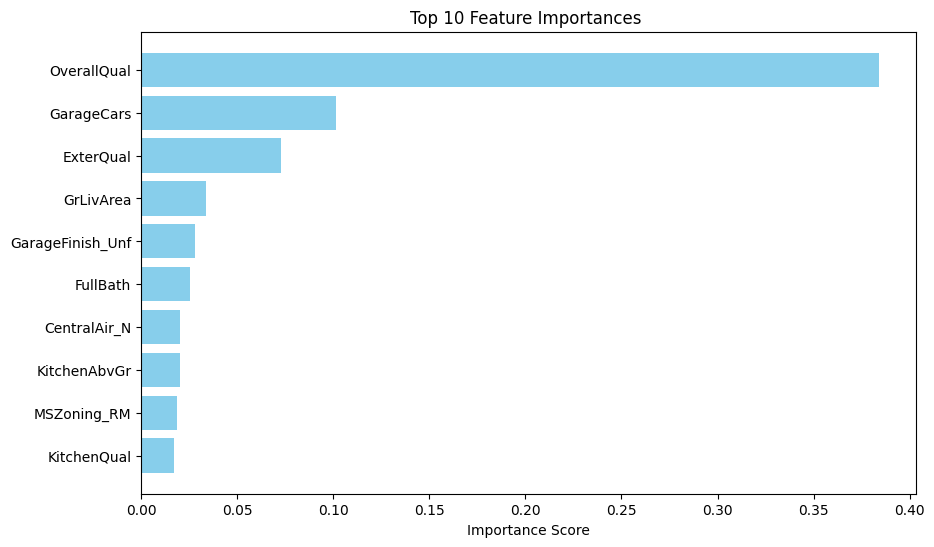

              Feature  Importance
0         OverallQual    0.384139
1          GarageCars    0.101694
2           ExterQual    0.072988
3           GrLivArea    0.033828
4    GarageFinish_Unf    0.027973
5            FullBath    0.025391
6        CentralAir_N    0.020334
7        KitchenAbvGr    0.020112
8         MSZoning_RM    0.018542
9         KitchenQual    0.017081
10           1stFlrSF    0.016194
11           BsmtQual    0.015162
12  GarageType_Attchd    0.014008
13       LotShape_Reg    0.013364
14        TotalBsmtSF    0.012526


In [68]:
import matplotlib.pyplot as plt

num_names = numeric_cols

# Get feature names created by One-Hot Encoding
ohe_names = list(
    my_pipeline.named_steps['preprocessor']
    .named_transformers_['cat_onehot']
    .named_steps['onehot']
    .get_feature_names_out(categorical_cols_one_hot)
)

# Ordinal columns keep the same names
ord_names = categorical_cols_ordinal

# Full feature list in model input order
all_feature_names = num_names + ohe_names + ord_names

# Extract feature importances from the model
importances = my_pipeline.named_steps['model'].feature_importances_

# Create a sorted DataFrame with feature importances
feat_importance = pd.DataFrame({
    'Feature': all_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

pd.set_option('display.max_rows', None)

# Plot top 10 most important features
plt.figure(figsize=(10, 6))
plt.barh(feat_importance['Feature'][:10],
         feat_importance['Importance'][:10],
         color='skyblue')
plt.gca().invert_yaxis()
plt.title('Top 10 Feature Importances ')
plt.xlabel('Importance Score')
plt.show()

print(feat_importance.head(15))


From this chart, we can observe that most features have a very small contribution to the model’s decision‑making process. After applying feature selection, the model becomes structurally simpler, requires fewer computations, reduces the risk of overfitting, and focuses only on the most informative variables, leading to better generalization performance.

In [69]:
def add_features(X):
    X_copy = X.copy()
    X_copy['TotalSF'] = X_copy['1stFlrSF'] + X_copy['2ndFlrSF'] + X_copy['TotalBsmtSF'] 
    X_copy['HouseAge'] = X_copy['YrSold'] - X_copy['YearBuilt']
    X_copy['TotalBath'] = X_copy['FullBath'] + (0.5 * X_copy['HalfBath']) + X_copy['BsmtFullBath']
    return X_copy
numeric_cols_extended = numeric_cols + ['TotalSF', 'HouseAge', 'TotalBath']


In [70]:
from sklearn.feature_selection import SelectFromModel
from sklearn.preprocessing import FunctionTransformer
selector = SelectFromModel(
    estimator=RandomForestRegressor(n_estimators=100, random_state=42),
    threshold=0.001
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numarical, numeric_cols_extended), 
        ('cat_onehot', one_hot_encoding, categorical_cols_one_hot),
        ('cat_ordinal', ordinal_encoding, categorical_cols_ordinal)
    ])
my_pipeline = Pipeline(steps=[
    ('feature_eng', FunctionTransformer(add_features)),
    ('preprocessor', preprocessor),
    ('feature_selection', selector), 
    #('model', RandomForestRegressor(n_estimators=200, random_state=42)) # MAE: 17121.5369   , 16343.7798
    ('model', XGBRegressor(n_estimators=750,
                           learning_rate=0.01,
                           random_state=0,
                           tree_method = 'hist',
                           device = 'cuda'
                          )) #MAE: 17169.8359375

   
])

my_pipeline.fit(X_train, y_train)

y_pred = my_pipeline.predict(X_valid)

score = mean_absolute_error(y_pred, y_valid)
print(f"MAE: {score}")

    

MAE: 15757.130859375


### Cross Validation 

In [71]:
from sklearn.model_selection import cross_val_score

# Multiply by -1 since sklearn calculates *negative* MAE
scores = -1 * cross_val_score(my_pipeline, train_data[valid_cols], y,
                              cv=5,
                              scoring='neg_mean_absolute_error')

print("MAE for each CV fold:", scores)
print("Average MAE:", scores.mean())

MAE for each CV fold: [16913.29492188 16167.97265625 16957.93554688 13807.40527344
 16916.21484375]
Average MAE: 16152.5646484375


The fact that the error on a single validation set (16343.77) is very close to the Cross‑Validation average (16693.42) is a good sign.

### (OPTIONAL)Evaluation of Random Forest performance for different numbers of trees using a full preprocessing and feature selection pipeline

In [72]:
# def get_score_rf(n_estimators ):
#     my_pipeline = Pipeline(steps=[
#     ('feature_eng', FunctionTransformer(add_features)),
#     ('preprocessor', preprocessor),
#     ('feature_selection', selector),
#     ('model', RandomForestRegressor(n_estimators = n_estimators, random_state=42))
#     ])
#     my_pipeline.fit(X_train, y_train)

#     y_pred = my_pipeline.predict(X_valid)
    
#     score = mean_absolute_error(y_pred, y_valid)
#     return score

# scores = {estimators: get_score_rf(estimators) for estimators in range (100, 701,50) }
# print(scores)
# print(f'Using {min(scores, key=scores.get )} estimators, the MAE reached its best value:{scores[min(scores, key=scores.get )]}')

### (OPTIONAL)Evaluation of XGBoost performance for different numbers of trees using a full preprocessing and feature selection pipeline

In [73]:
# def get_score_xgb(n_estimators  ,learning_rate):
#     my_pipeline = Pipeline(steps=[
#     ('feature_eng', FunctionTransformer(add_features)),
#     ('preprocessor', preprocessor),
#     ('feature_selection', selector),
#     ('model', XGBRegressor(n_estimators=n_estimators, learning_rate=learning_rate, random_state=0))
#     ])
#     my_pipeline.fit(X_train, y_train)

#     y_pred = my_pipeline.predict(X_valid)
    
#     score = mean_absolute_error(y_pred, y_valid)
#     return score

# scores = {estimators: get_score_xgb(estimators, learning_rate=0.01) for estimators in range (500, 2001,100) }
# print(scores)
# print()
# print(f'Using {min(scores, key=scores.get )} estimators, the MAE reached its best value:{scores[min(scores, key=scores.get )]}')

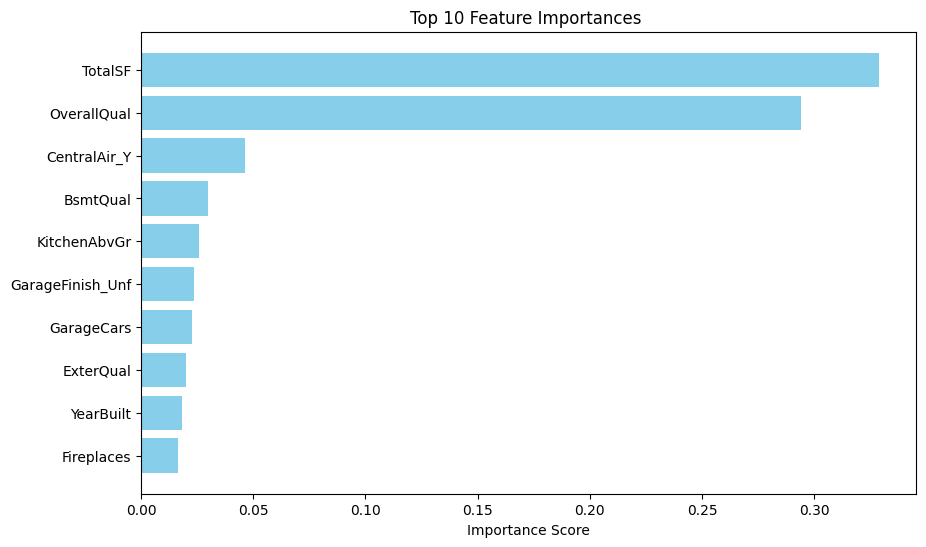

             Feature  Importance
0            TotalSF    0.328977
1        OverallQual    0.294340
2       CentralAir_Y    0.046467
3           BsmtQual    0.029777
4       KitchenAbvGr    0.025741
5   GarageFinish_Unf    0.023479
6         GarageCars    0.022659
7          ExterQual    0.019920
8          YearBuilt    0.018148
9         Fireplaces    0.016419
10       MSZoning_RM    0.016409
11          2ndFlrSF    0.015907
12       KitchenQual    0.015319
13         TotalBath    0.012338
14       OverallCond    0.010817
15          HouseAge    0.010499
16         GrLivArea    0.010299
17      LotShape_Reg    0.010276
18      YearRemodAdd    0.008198
19        BsmtFinSF1    0.008051
20        GarageArea    0.006188
21          FullBath    0.006058
22           LotArea    0.005294
23         BsmtUnfSF    0.004862
24       TotalBsmtSF    0.003476
25   BsmtExposure_Gd    0.003472
26       FireplaceQu    0.003233
27          1stFlrSF    0.002819
28        WoodDeckSF    0.002673
29       S

In [74]:
# 1. Retrieve all feature names after preprocessing (as before)
num_names = numeric_cols_extended
ohe_names = list(my_pipeline.named_steps['preprocessor']
                 .named_transformers_['cat_onehot']
                 .named_steps['onehot']
                 .get_feature_names_out(categorical_cols_one_hot))
ord_names = categorical_cols_ordinal
all_feature_names_before_selection = num_names + ohe_names + ord_names

# 2. FIND WHICH FEATURES WERE SELECTED BY 'SelectFromModel'
# get_support() returns a True/False mask for each feature
selector = my_pipeline.named_steps['feature_selection']
selected_mask = selector.get_support()

# Filter feature names using the selector mask
final_feature_names = [
    name for name, selected in zip(all_feature_names_before_selection, selected_mask)
    if selected
]

# 3. Extract feature importances from the final model
importances = my_pipeline.named_steps['model'].feature_importances_

# 4. Now the lengths match! Create the DataFrame
feat_importance = pd.DataFrame({
    'Feature': final_feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

# Plot top 10 most important features
plt.figure(figsize=(10, 6))
plt.barh(feat_importance['Feature'][:10],
         feat_importance['Importance'][:10],
         color='skyblue')
plt.gca().invert_yaxis()
plt.title('Top 10 Feature Importances ')
plt.xlabel('Importance Score')
plt.show()


print(feat_importance)


From the chart, we can see that the engineered features played an important role in the model’s decisions.

## Insights

### In the context of this dataset, where house prices can reach several hundred thousand dollars, an error of around 16,000 is a fairly solid result. For example, if a house costs 180,000, the model would miss the prediction by roughly 8.8% (16,000/180,000). In the real‑estate domain, such an error is acceptable, since a home’s price often depends on subjective factors, such as negotiation.

# Update: 23-05-2026

In [75]:
!pip install pygad

In [76]:
import pygad
import time
import joblib # Library for saving the model

#  Created a pipeline only for transformations
transformation_pipeline = Pipeline(steps=my_pipeline.steps[:-1])

#  Fit & Transform, useful for GPU
X_train_final = transformation_pipeline.fit_transform(X_train, y_train).astype('float32')
X_valid_final = transformation_pipeline.transform(X_valid).astype('float32')



def fitness_func(ga_instance, solution, solution_idx):
    n_est = int(solution[0])
    lr = solution[1]
    depth = int(solution[2])

    # # Injecting the parameters into the pipeline
    # my_pipeline.set_params(
    #     model__n_estimators = n_est,
    #     model__learning_rate = lr,
    #     model__max_depth = depth
    # )

    # my_pipeline.fit(X_train, y_train)

    # preds = my_pipeline.predict(X_valid)
    # score = mean_absolute_error(preds, y_valid)
  
    final_model = XGBRegressor(
        n_estimators=n_est,
        learning_rate=lr,
        max_depth = depth,
        random_state=0,
        tree_method='hist',
        device='cuda',
        n_jobs=-1
    )
    
    # Training
    ## X_train and X_valid for cpu
    # X_train_final and X_valid_final for GPU
    
    final_model.fit(X_train_final, y_train)
    
    # Prediction
    y_pred = final_model.predict(X_valid_final)
    score = mean_absolute_error(y_pred, y_valid)
    print(f"MAE : {score}")

    # Higher fitness for lower MAE
    fitness = 1.0 / (score + 0.01)
    return fitness

# Defining the search space (Genes)
gene_space =  [
    range(50, 2001, 50),        # n_estimators
    np.linspace(0.01, 0.2, 20),  # learning_rate
    range(2, 10)                 # max_depth
]

ga_instance = pygad.GA(
    num_generations = 20,              # Number of generations (evolution cycles)
    num_parents_mating = 5,            # Number of parents for the next generation
    fitness_func = fitness_func,
    sol_per_pop = 10,                  # Population size (configurations per generation)
    num_genes = len(gene_space),
    gene_space = gene_space, 
    parent_selection_type = 'sss',      # Steady-state selection
    keep_parents = 1,
    crossover_type = 'single_point',
    mutation_type = 'random',
    mutation_probability = 0.1
)

print("Starting genetic optimization...")
start_time = time.perf_counter()
ga_instance.run()
end_time = time.perf_counter()

# 5. Results
solution, solution_fitness, solution_idx = ga_instance.best_solution()
print("-" * 30)
print(f"Best configuration found: \n n_estimators: {int(solution[0])}, learning_rate: {solution[1]:.4f}, max_depth: {int(solution[2])}")
print(f"Best MAE: {1.0/solution_fitness - 0.01:.2f}")
print(f'Optimization completed in:{((end_time-start_time)/60):.2f} min')
print("-" * 30)

Starting genetic optimization...
MAE : 16425.275390625
MAE : 15955.5810546875
MAE : 16773.00390625
MAE : 15159.5927734375
MAE : 15304.1611328125
MAE : 15091.51171875
MAE : 15369.6767578125
MAE : 16583.359375
MAE : 16713.708984375
MAE : 17342.708984375
MAE : 15418.744140625
MAE : 16844.990234375
MAE : 15608.9248046875
MAE : 15030.498046875
MAE : 15163.9658203125
MAE : 15974.9033203125
MAE : 16131.830078125
MAE : 15210.755859375
MAE : 15000.6171875
MAE : 15213.896484375
MAE : 15787.9755859375
MAE : 16344.0634765625
MAE : 16891.6875
MAE : 15969.412109375
MAE : 16891.68359375
MAE : 15963.697265625
MAE : 17793.556640625
MAE : 15072.61328125
MAE : 16007.0478515625
MAE : 15017.9775390625
MAE : 14928.2626953125
MAE : 15969.412109375
MAE : 15758.34375
MAE : 14730.5888671875
MAE : 16337.982421875
MAE : 16891.68359375
MAE : 14771.900390625
MAE : 16865.236328125
MAE : 15073.7470703125
MAE : 14729.470703125
MAE : 15072.61328125
MAE : 15194.060546875
MAE : 15824.2578125
MAE : 15750.2734375
MAE : 148

In [77]:
# 1. Extract optimal parameters from the Genetic Algorithm (GA)
best_n_estimators = int(solution[0])
best_learning_rate = solution[1]
best_max_depth = int(solution[2])

# 2. Retrain the final model with these parameters on the transformed training data
# We use X_train_final to maintain consistency with what the GA evaluated
final_model = XGBRegressor(
    n_estimators=best_n_estimators,
    learning_rate=best_learning_rate,
    max_depth=best_max_depth,
    random_state=0,
    tree_method='hist',
    device='cuda'
)

final_model.fit(X_train_final, y_train)

# 3. Sanity Check - the score should be identical to the best score found by the GA
preds_val = final_model.predict(X_valid_final)
final_mae = mean_absolute_error(y_valid, preds_val)
print(f"Confirmed MAE: {final_mae:.2f}")

Confirmed MAE: 14709.99


In [78]:
# Create the monolithic Pipeline
# Note: transformation_pipeline must already be .fit() on the training data
full_production_pipeline = Pipeline(steps=[
    ('transformation', transformation_pipeline),
    ('model', final_model)
])

# Save the model
joblib.dump(full_production_pipeline, 'house_price_model.pkl')
print("Model successfully saved as 'house_price_model.pkl'")

Model successfully saved as 'house_price_model.pkl'


### Latest result:  MAE = 14.709
### For example, if a house costs 180,000, the model would miss the prediction by roughly 8.16% (14,709/180,000).